# Risk and Return Analysis (Refined)
This notebook revisits the original analysis with clearer data loading, reusable helpers, and metrics that distinguish information ratio (vs. benchmark) from the classic Sharpe ratio (vs. risk-free rate).

In [10]:
from pathlib import Path
from IPython.display import display
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

In [11]:
sns.set_theme(context='notebook', style='darkgrid', palette='deep')
plt.rcParams.update({'figure.figsize': (14, 5), 'axes.titlesize': 14})

## Paths and data loading
We explicitly parse the `Date` column while leaving other columns untouched. The helper asserts that files exist before attempting to read them.

In [12]:
DATA_DIR = Path('.')
STOCK_PATH = DATA_DIR / 'stock_data.csv'
BENCHMARK_PATH = DATA_DIR / 'benchmark_data.csv'

assert STOCK_PATH.exists(), f'Missing file: {STOCK_PATH}'
assert BENCHMARK_PATH.exists(), f'Missing file: {BENCHMARK_PATH}'

stock_data_raw = pd.read_csv(
    STOCK_PATH,
    parse_dates=['Date'],
    index_col='Date'
)
benchmark_data_raw = pd.read_csv(
    BENCHMARK_PATH,
    parse_dates=['Date'],
    index_col='Date'
)

print(f'Stock data shape (raw): {stock_data_raw.shape}')
print(f'Benchmark data shape (raw): {benchmark_data_raw.shape}')

Stock data shape (raw): (252, 2)
Benchmark data shape (raw): (261, 1)


## Cleaning and quick inspection
We work on copies to preserve the raw frames. Dropping missing rows keeps return calculations well-defined.

In [13]:
stock_data = stock_data_raw.dropna().copy()
benchmark_data = benchmark_data_raw.dropna().copy()

def summarize_dataframe(name: str, df: pd.DataFrame, head: int = 5) -> None:
    """Display a compact summary with head/tail and descriptive statistics."""
    print(f'\n{name} — shape: {df.shape}')
    display(df.head(head))
    display(df.tail(head))
    display(df.describe(include='all'))

summarize_dataframe('Stocks', stock_data)
summarize_dataframe('Benchmark', benchmark_data)


Stocks — shape: (252, 2)


,Amazon,Facebook
Date,,
2016-01-04,636.989990,102.220001
2016-01-05,633.789978,102.730003
2016-01-06,632.650024,102.970001
2016-01-07,607.940002,97.919998
2016-01-08,607.049988,97.330002


,Amazon,Facebook
Date,,
2016-12-23,760.590027,117.269997
2016-12-27,771.400024,118.010002
2016-12-28,772.130005,116.919998
2016-12-29,765.150024,116.349998
2016-12-30,749.869995,115.050003


,Amazon,Facebook
count,252.000000,252.000000
mean,699.523135,117.035873
std,92.362312,8.899858
min,482.070007,94.160004
25%,606.929993,112.202499
50%,727.875000,117.765000
75%,767.882492,123.902502
max,844.359985,133.279999



Benchmark — shape: (252, 1)


,S&P 500
Date,
2016-01-04,2012.66
2016-01-05,2016.71
2016-01-06,1990.26
2016-01-07,1943.09
2016-01-08,1922.03


,S&P 500
Date,
2016-12-23,2263.79
2016-12-27,2268.88
2016-12-28,2249.92
2016-12-29,2249.26
2016-12-30,2238.83


,S&P 500
count,252.000000
mean,2094.651310
std,101.427615
min,1829.080000
25%,2047.060000
50%,2104.105000
75%,2169.075000
max,2271.720000


## Helper utilities
Reusable helpers keep plotting and metric computation concise and repeatable.

In [14]:
def plot_price_series(stock_df: pd.DataFrame, benchmark_df: pd.DataFrame) -> None:
    fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    stock_df.plot(ax=axes[0], title='Adjusted Close Prices')
    benchmark_df.plot(ax=axes[1], color='grey', title='Benchmark Index')
    axes[1].grid(alpha=0.3)
    plt.tight_layout()

def plot_return_series(stock_returns: pd.DataFrame, benchmark_returns: pd.DataFrame) -> None:
    fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    stock_returns.plot(ax=axes[0], title='Daily Returns — Stocks')
    benchmark_returns.plot(ax=axes[1], color='grey', title='Daily Returns — Benchmark')
    axes[0].axhline(0, color='white', linewidth=0.5, linestyle='--', alpha=0.7)
    axes[1].axhline(0, color='white', linewidth=0.5, linestyle='--', alpha=0.7)
    plt.tight_layout()

def compute_information_ratio(stock_returns: pd.DataFrame, benchmark_series: pd.Series) -> pd.Series:
    relative = stock_returns.sub(benchmark_series, axis=0)
    return relative.mean() / relative.std()

def compute_sharpe_ratio(stock_returns: pd.DataFrame, risk_free_rate_annual: float = 0.015, trading_days: int = 252) -> pd.Series:
    daily_rf = (1 + risk_free_rate_annual) ** (1 / trading_days) - 1
    excess_vs_rf = stock_returns.sub(daily_rf)
    return excess_vs_rf.mean() / excess_vs_rf.std()

def annualize_ratio(daily_ratio: pd.Series, trading_days: int = 252) -> pd.Series:
    return daily_ratio * np.sqrt(trading_days)

Thanks for checking—happy to clarify. Plan: explain why the notebook uses `RISK_FREE_RATE_ANNUAL = 0.015` and show how you can set a rate that matches your study period.

---

### where the 1.5% came from
I set it as a conservative placeholder representing a rough 1.5% annual yield, which is close to U.S. Treasury rates during parts of 2016. It isn’t sourced from a dataset inside the project; it’s just a default so the Sharpe calculation runs without failing.

### how to pick a better rate
- Pull the actual risk-free series (e.g., 3-month T-bill or 10-year Treasury) covering 2016 from FRED, Quandl, or another data provider.
- Convert the annualized rate to the daily equivalent before subtracting it from returns. In the notebook, this is done with  
  ```python
  daily_rf = (1 + risk_free_rate_annual) ** (1 / trading_days) - 1
  ```
- Replace the constant with the value computed from your data—for example, the mean yield across the window or even a time-varying daily series if you want precision.

### quick refinement option
If you already have a CSV of Treasury yields:


In [ ]:
treasury = pd.read_csv('risk_free.csv', parse_dates=['Date'], index_col='Date')
risk_free_rate_annual = treasury.loc['2016-01-01':'2016-12-30', 'Yield'].mean() / 100

Then pass that variable into the Sharpe helper.

---

In short: the 1.5% was a placeholder; swap it out with the actual yield for your analysis period to keep the Sharpe numbers grounded in reality.

## Price exploration

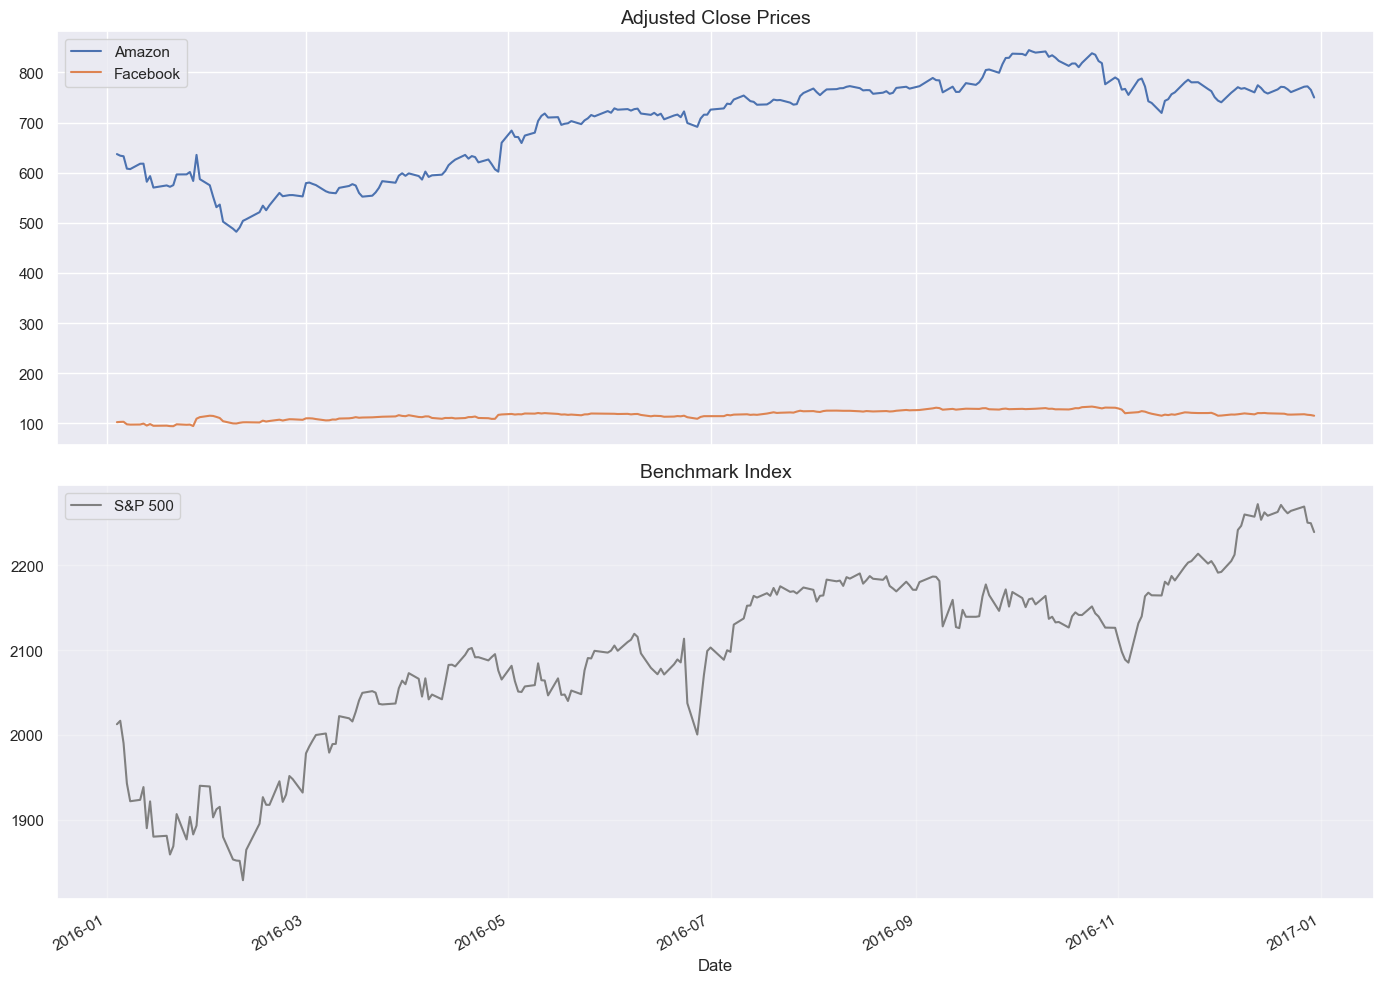

In [15]:
plot_price_series(stock_data, benchmark_data)

## Return calculations
We compute simple daily returns, drop the initial `NaN`, and visualize them.

Stock returns shape: (251, 2)
Benchmark returns shape: (251, 1)


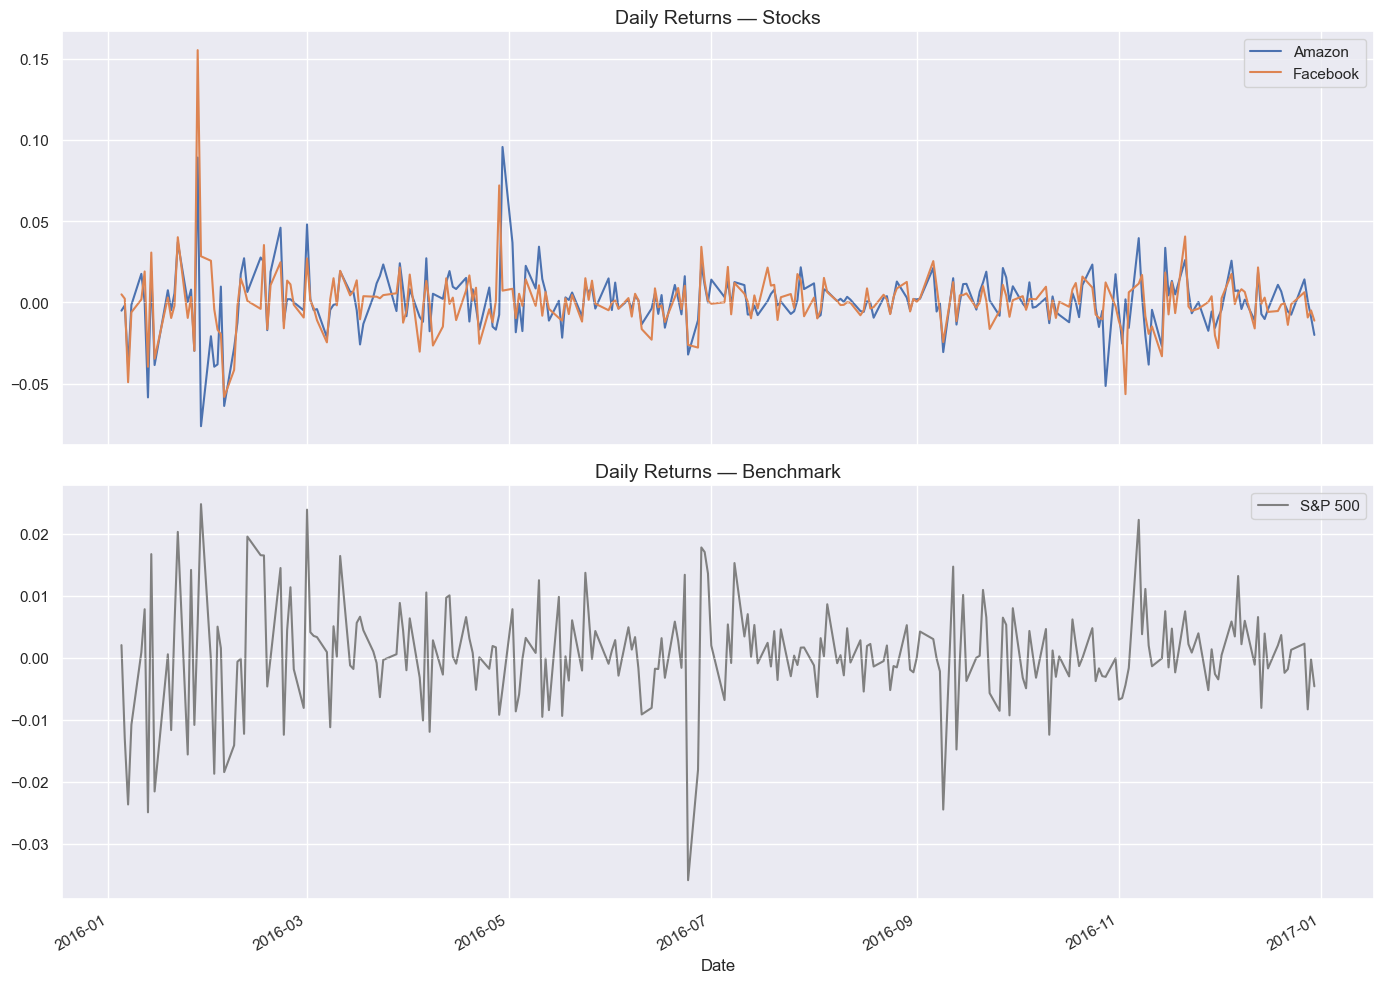

In [16]:
stock_returns = stock_data.pct_change().dropna()
benchmark_returns = benchmark_data.pct_change().dropna()

print(f'Stock returns shape: {stock_returns.shape}')
print(f'Benchmark returns shape: {benchmark_returns.shape}')

plot_return_series(stock_returns, benchmark_returns)

## Information ratio vs. benchmark
Subtracting benchmark returns yields the information ratio (risk-adjusted performance relative to S&P 500).

,daily_information_ratio,annual_information_ratio
Amazon,0.022318,0.354283
Facebook,0.010856,0.172329


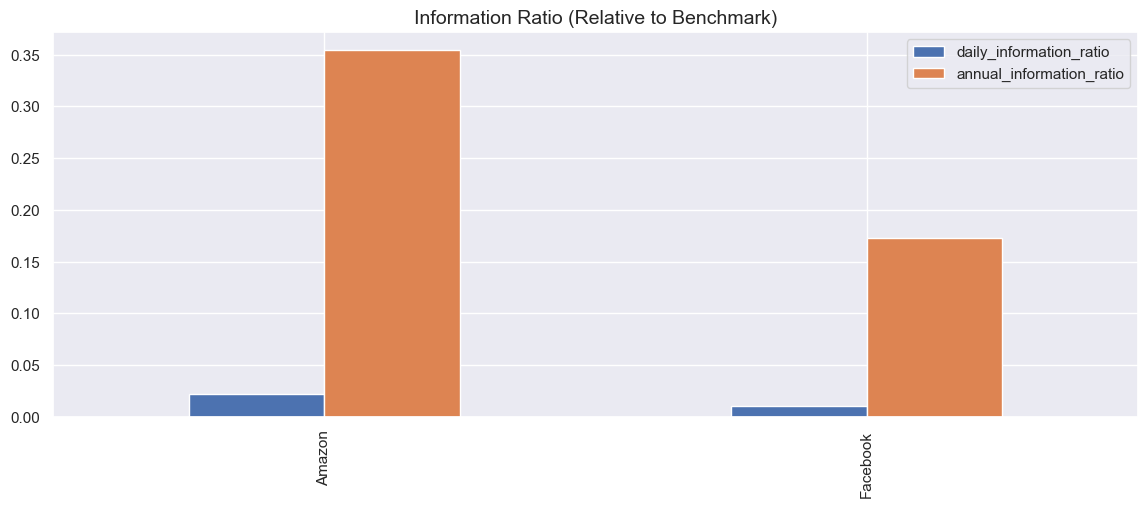

In [17]:
aligned = stock_returns.join(benchmark_returns, how='inner')
benchmark_series = aligned['S&P 500']
stock_only = aligned.drop(columns=['S&P 500'])

information_ratio_daily = compute_information_ratio(stock_only, benchmark_series)
information_ratio_annual = annualize_ratio(information_ratio_daily)

info_summary = pd.DataFrame({
    'daily_information_ratio': information_ratio_daily,
    'annual_information_ratio': information_ratio_annual
})
display(info_summary)
info_summary.plot(kind='bar', title='Information Ratio (Relative to Benchmark)')
plt.show()

## Sharpe ratio vs. risk-free rate
Using a configurable annual risk-free rate (default 1.5%) we compute the classic Sharpe ratio.

,daily_sharpe_ratio,annual_sharpe_ratio
Amazon,0.041277,0.655250
Facebook,0.031753,0.504071


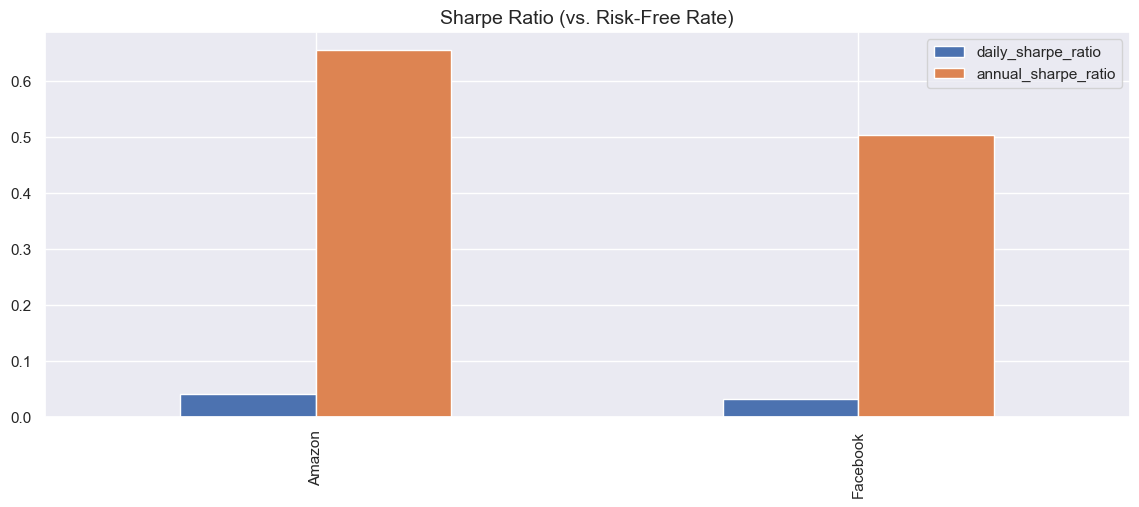

In [18]:
RISK_FREE_RATE_ANNUAL = 0.015  # Adjust if you have a more precise estimate

sharpe_daily = compute_sharpe_ratio(stock_only, risk_free_rate_annual=RISK_FREE_RATE_ANNUAL)
sharpe_annual = annualize_ratio(sharpe_daily)

sharpe_summary = pd.DataFrame({
    'daily_sharpe_ratio': sharpe_daily,
    'annual_sharpe_ratio': sharpe_annual
})
display(sharpe_summary)
sharpe_summary.plot(kind='bar', title='Sharpe Ratio (vs. Risk-Free Rate)')
plt.show()

## Findings
- Information ratio captures excess performance relative to the S&P 500. Positive values indicate outperformance after adjusting for volatility.
- Sharpe ratio contextualizes returns relative to a risk-free alternative. Annualized values above 1 are generally considered strong.
- Update `RISK_FREE_RATE_ANNUAL` if you have Treasury yield data for the study window.